# 📊 Visual Analysis of U.S. Monetary Policy

## 🧠 Introduction

Monetary policy plays a central role in shaping inflation, labor market conditions, and overall economic stability. The Federal Funds Rate is one of the Federal Reserve’s primary tools for influencing borrowing costs and managing macroeconomic conditions.

This notebook focuses on the **visual analysis and interpretation** of the Federal Funds Rate alongside key economic indicators, including **inflation** and **unemployment**. Rather than emphasizing raw data preparation, this notebook is designed to communicate the analytical story through charts and concise interpretation.

By examining long-term trends and variable relationships, this analysis highlights how monetary policy changes over time and how interest rate decisions interact with broader economic conditions.

## 🎯 Analytical Objective

The goal of this notebook is to visually analyze how the Federal Funds Rate has evolved over time and how it relates to inflation and unemployment across different macroeconomic environments.

## 📂 Load and Prepare Data

This analysis uses a cleaned macroeconomic dataset containing the Federal Funds Rate, CPI, unemployment, and year-over-year inflation.

Before visualization, the data is prepared by:
- converting the date field into a datetime format,
- sorting observations chronologically,
- cleaning percentage-based inflation values,
- and creating rolling averages to smooth short-term volatility.

This preparation step ensures that the charts focus on meaningful long-run trends rather than formatting issues or monthly noise.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("data/macro_dashboard_clean.csv")

# Convert and sort dates
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").copy()

# Clean Inflation YoY (remove % and convert to numeric)
df["Inflation YoY"] = (
    df["Inflation YoY"]
    .astype(str)
    .str.replace("%", "", regex=False)
)
df["Inflation YoY"] = pd.to_numeric(df["Inflation YoY"], errors="coerce")

# Create additional fields
df["Fed Rate Change"] = df["Fed Rate"].diff()
df["Fed Rate Rolling"] = df["Fed Rate"].rolling(window=12).mean()
df["Inflation Rolling"] = df["Inflation YoY"].rolling(window=12).mean()
df["Unemployment Rolling"] = df["Unemployment"].rolling(window=12).mean()

# Optional recent subset for modern trends
recent_df = df[df["Date"] >= "2000-01-01"].copy()

# General plotting style
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Quick check
df[["Date", "Fed Rate", "Inflation YoY", "Unemployment"]].head()

,Date,Fed Rate,Inflation YoY,Unemployment
0,1954-07-01,0.80,NaN,5.8
1,1954-08-01,1.22,NaN,6.0
2,1954-09-01,1.07,NaN,6.1
3,1954-10-01,0.85,NaN,5.7
4,1954-11-01,0.83,NaN,5.3


## 📈 Visual Analysis of Monetary Policy Trends

With the data prepared, the next section examines how the Federal Funds Rate has evolved over time and how it relates to inflation and unemployment.

The charts are designed to move from broad historical context to more specific macroeconomic relationships, allowing the analysis to build logically from overall policy behavior to variable interaction.

## 📈 Chart 1: Federal Funds Rate Over Time

This chart provides a long-run view of the Federal Funds Rate, establishing the foundation for understanding how monetary policy has evolved across different economic periods.

By examining rate levels over time, we can identify broad shifts between restrictive and accommodative policy environments before exploring more detailed relationships with other macroeconomic variables.

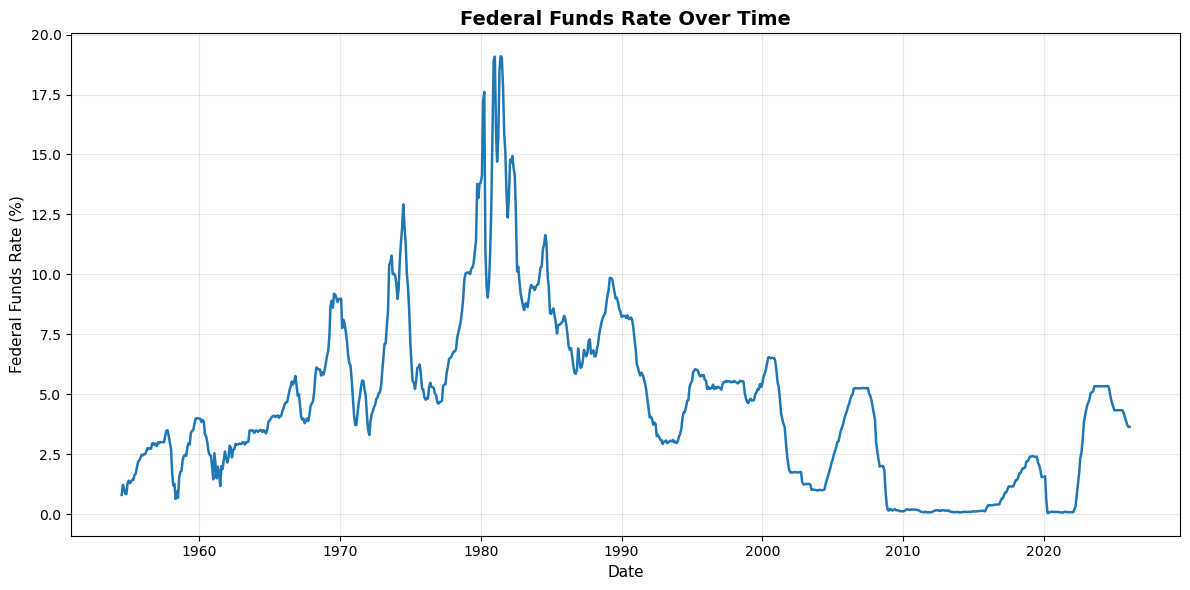

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(df["Date"], df["Fed Rate"], linewidth=1.8)

plt.title("Federal Funds Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Federal Funds Rate (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Interpretation

The long-term trajectory of the Federal Funds Rate highlights distinct monetary policy regimes across decades. Periods of elevated interest rates tend to align with inflationary environments where the Federal Reserve adopted a restrictive stance, while lower-rate periods reflect accommodative policy used to support economic recovery.

This view provides important historical context by showing how policy direction changes over time. However, rate levels alone do not fully capture the timing or intensity of policy decisions. To better understand how the Federal Reserve responds to changing economic conditions, it is necessary to examine rate movements alongside other macroeconomic indicators such as inflation and unemployment.

## 📉 Chart 2: Inflation and the Federal Funds Rate

After establishing the long-run path of the Federal Funds Rate, the next step is to examine how monetary policy relates to inflation.

Inflation is one of the Federal Reserve’s most important policy considerations. Comparing inflation and the Federal Funds Rate over time helps show how policy tends to respond to changing price conditions and whether tighter monetary policy tends to emerge during higher-inflation environments.

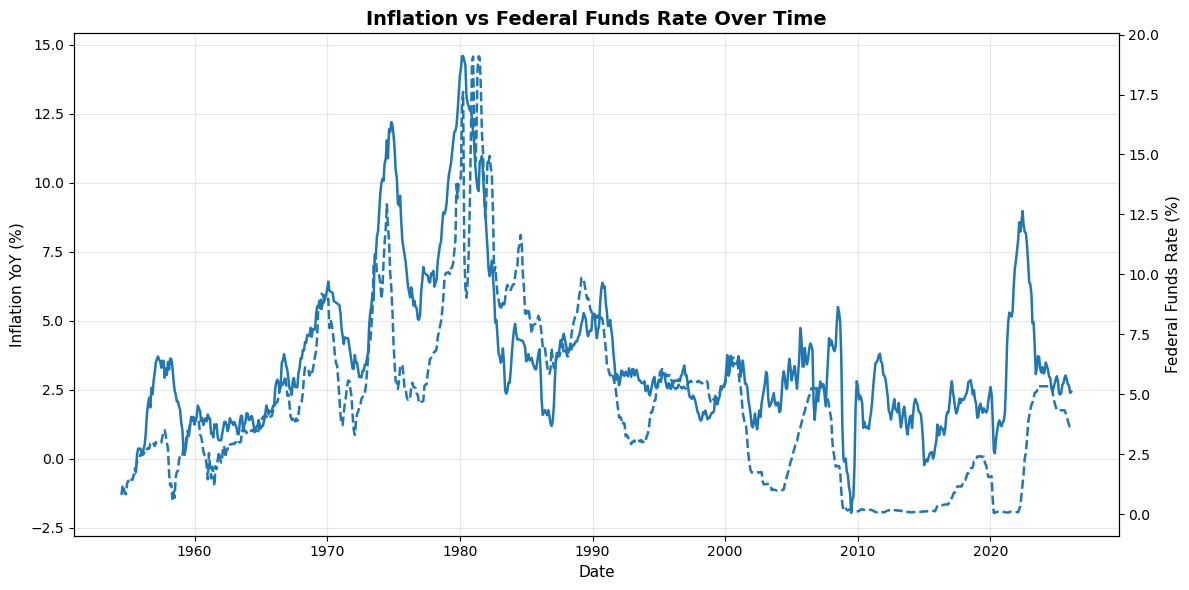

In [6]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df["Date"], df["Inflation YoY"], linewidth=1.8)
ax1.set_xlabel("Date")
ax1.set_ylabel("Inflation YoY (%)")

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Fed Rate"], linestyle="--", linewidth=1.8)
ax2.set_ylabel("Federal Funds Rate (%)")

ax1.grid(alpha=0.3)
plt.title("Inflation vs Federal Funds Rate Over Time")
fig.tight_layout()
plt.show()

### 📊 Interpretation

The relationship between inflation and the Federal Funds Rate suggests that higher inflation environments often coincide with tighter monetary policy. As inflationary pressure increases, the Federal Reserve tends to raise interest rates in an effort to moderate demand and stabilize prices.

At the same time, the relationship is not perfectly synchronized or linear. There are periods where inflation and interest rates do not move together immediately, reflecting the fact that policy decisions are shaped by multiple factors, including employment conditions, financial stability, and expectations about future economic performance.

This chart strengthens the analysis by showing that monetary policy is responsive to inflation, but not mechanical. Interest rate decisions reflect broader economic judgment rather than a reaction to a single variable alone.

## 👩‍💼 Chart 3: Unemployment and the Federal Funds Rate

Inflation is only one side of the monetary policy equation. The Federal Reserve also considers labor market conditions when setting interest rates.

Comparing unemployment with the Federal Funds Rate helps illustrate how policy shifts across stronger and weaker economic environments. This view adds another layer to the analysis by showing how monetary policy reflects the Federal Reserve’s effort to balance price stability with employment conditions.

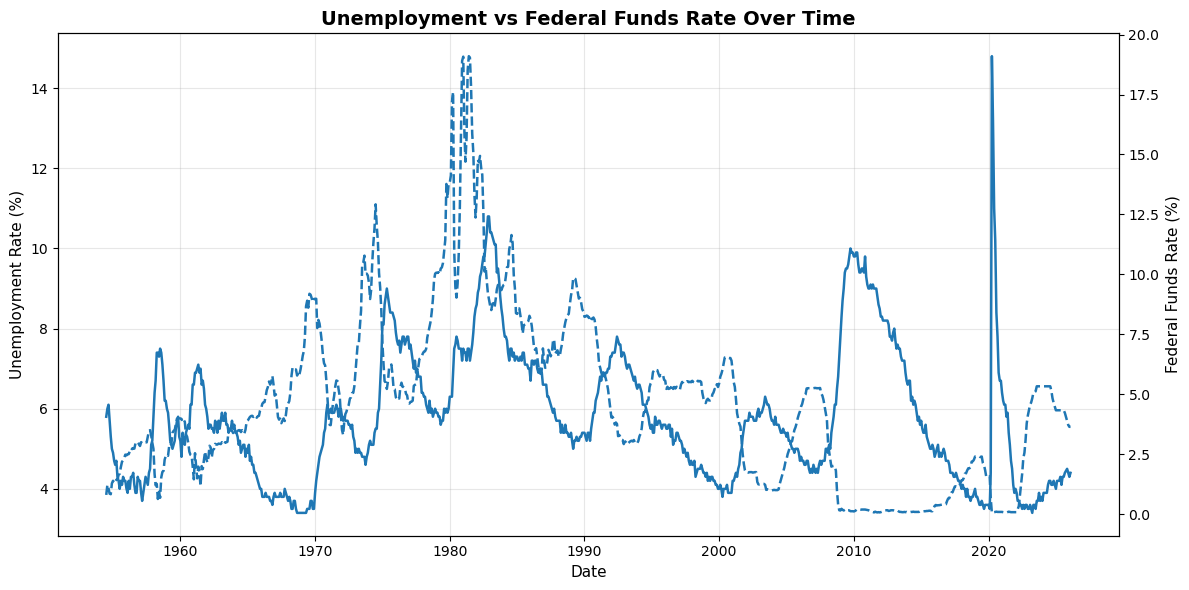

In [7]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df["Date"], df["Unemployment"], linewidth=1.8)
ax1.set_xlabel("Date")
ax1.set_ylabel("Unemployment Rate (%)")

ax2 = ax1.twinx()
ax2.plot(df["Date"], df["Fed Rate"], linestyle="--", linewidth=1.8)
ax2.set_ylabel("Federal Funds Rate (%)")

ax1.grid(alpha=0.3)
plt.title("Unemployment vs Federal Funds Rate Over Time")
fig.tight_layout()
plt.show()

### 📊 Interpretation

The relationship between unemployment and the Federal Funds Rate reflects the balancing act at the center of monetary policy. Periods of higher unemployment often align with lower interest rates, suggesting accommodative policy intended to support economic activity and labor market recovery.

In contrast, stronger labor market conditions may allow for tighter monetary policy, particularly when inflationary pressures are also present. This pattern highlights the trade-offs embedded in Federal Reserve decision-making, where policymakers must weigh both employment and price stability rather than focusing on a single objective.

This chart adds important depth to the analysis by showing that interest rate decisions are tied not only to inflation, but also to the broader strength of the economy.

## 🔍 Chart 4: Recent Macroeconomic Trends Since 2000

While the full historical view provides long-run context, focusing on the modern period makes recent monetary policy behavior easier to interpret.

To highlight broader trends rather than short-term fluctuations, this chart uses 12-month rolling averages for the Federal Funds Rate, inflation, and unemployment. This approach smooths volatility and provides a clearer view of how these variables evolve together over time.

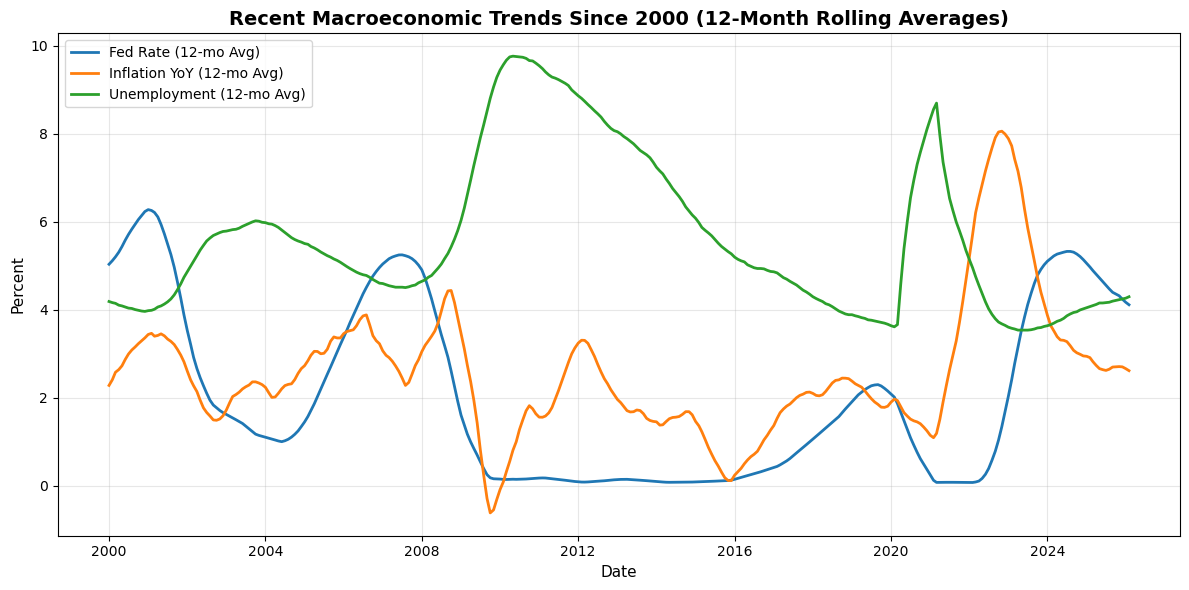

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(
    recent_df["Date"],
    recent_df["Fed Rate Rolling"],
    linewidth=2,
    label="Fed Rate (12-mo Avg)"
)

plt.plot(
    recent_df["Date"],
    recent_df["Inflation Rolling"],
    linewidth=2,
    label="Inflation YoY (12-mo Avg)"
)

plt.plot(
    recent_df["Date"],
    recent_df["Unemployment Rolling"],
    linewidth=2,
    label="Unemployment (12-mo Avg)"
)

plt.title("Recent Macroeconomic Trends Since 2000 (12-Month Rolling Averages)")
plt.xlabel("Date")
plt.ylabel("Percent")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 📊 Interpretation

Focusing on the post-2000 period highlights how monetary policy has evolved in more recent economic environments. Using rolling averages helps reduce short-term volatility and makes longer-term trends easier to interpret.

This view reveals prolonged periods of low interest rates following major economic disruptions, as well as gradual adjustments in response to changing inflation and labor market conditions. Compared to earlier decades, recent policy behavior reflects extended accommodative phases followed by more measured normalization.

By examining interest rates alongside inflation and unemployment in a smoothed format, this chart provides a more decision-oriented perspective on modern monetary policy and reinforces the interconnected nature of macroeconomic variables.

## 🔍 Key Findings

- The Federal Funds Rate exhibits clear long-run policy regimes, shifting between restrictive and accommodative environments over time.

- Rate changes provide clearer insight into monetary policy actions than rate levels alone, highlighting periods of active intervention and policy transitions.

- Higher inflation environments are often associated with tighter monetary policy, though the relationship is not strictly linear and varies across economic conditions.

- Lower interest rate periods frequently align with weaker labor market conditions, suggesting accommodative policy during periods of economic stress.

- Recent decades show prolonged low-rate environments and more gradual policy adjustments, reflecting shifts in modern monetary policy behavior.

## ⚠️ Limitations

- This analysis is exploratory and does not establish causality between interest rates, inflation, and unemployment.

- The relationships observed between variables are descriptive and may be influenced by additional macroeconomic factors not included in the dataset.

- Some early-period data, particularly inflation, contains missing values, which may limit interpretation in earlier years.

- Monthly data may smooth over short-term policy changes or intra-period rate adjustments.

- The analysis does not incorporate external drivers such as fiscal policy, global economic conditions, or market expectations, which also influence Federal Reserve decisions.

## 🚀 Next Steps

- Incorporate additional macroeconomic variables to better capture the full set of factors influencing monetary policy.

- Apply statistical methods such as correlation analysis or regression models to quantify relationships between interest rates, inflation, and unemployment.

- Segment the analysis by monetary policy eras to identify structural differences across time periods.

- Add recession indicators to provide stronger economic context for policy shifts.

- Develop an interactive dashboard to allow dynamic exploration of trends and relationships.

- Explore time-series forecasting techniques to predict future interest rate movements.